   Morse Potential (5 Vibrational Levels, Extended Y-axis)
→ Plotting HCl
Mounted at /content/drive


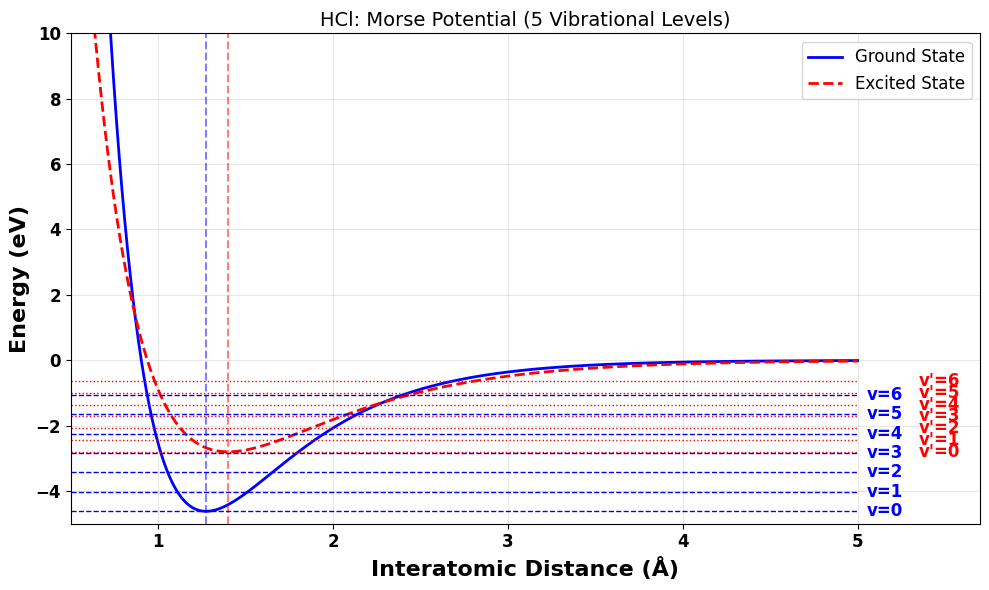

→ Plotting HBr
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


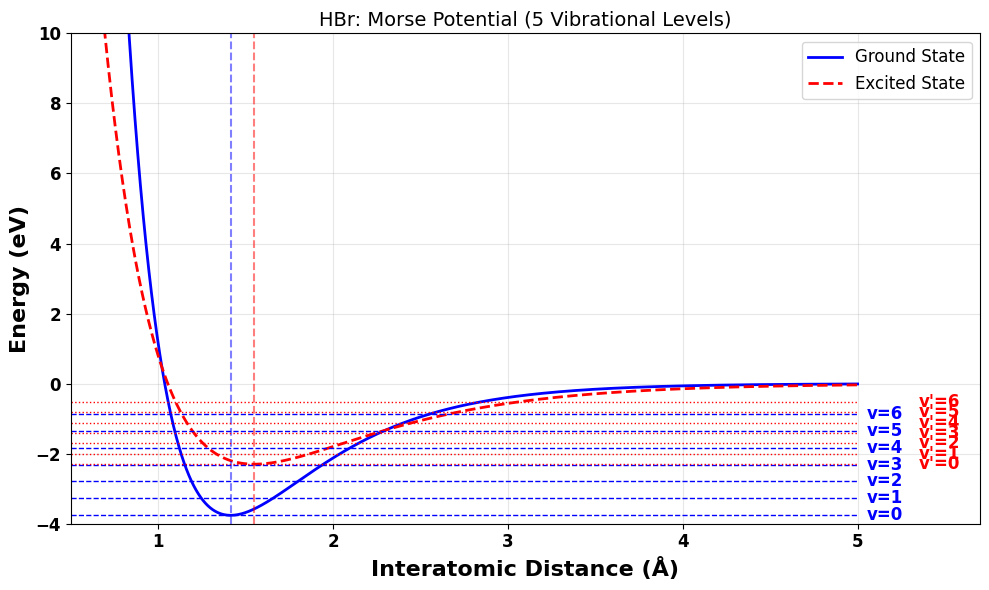

→ Plotting HI
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


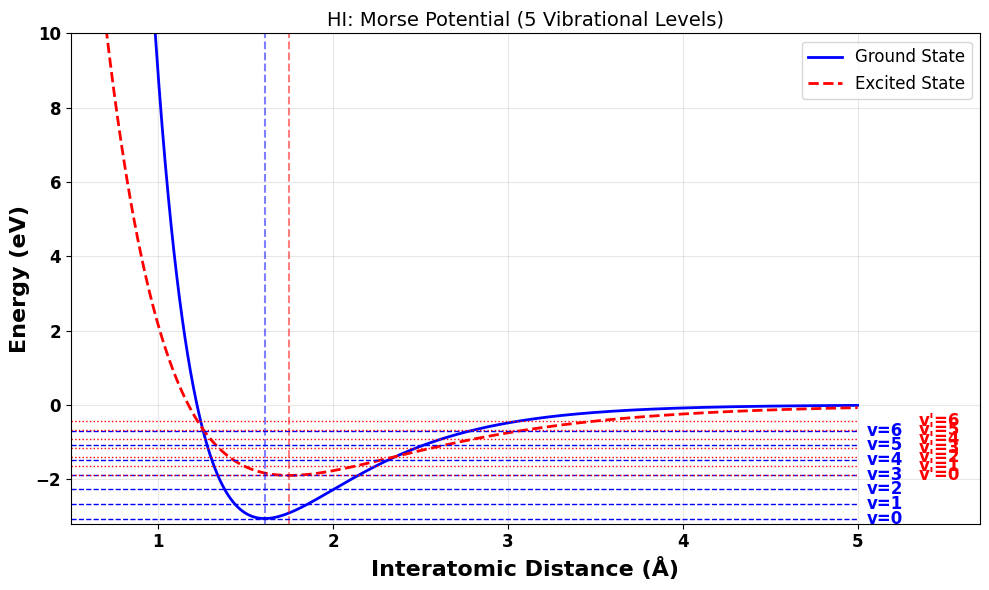

→ Plotting HF
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


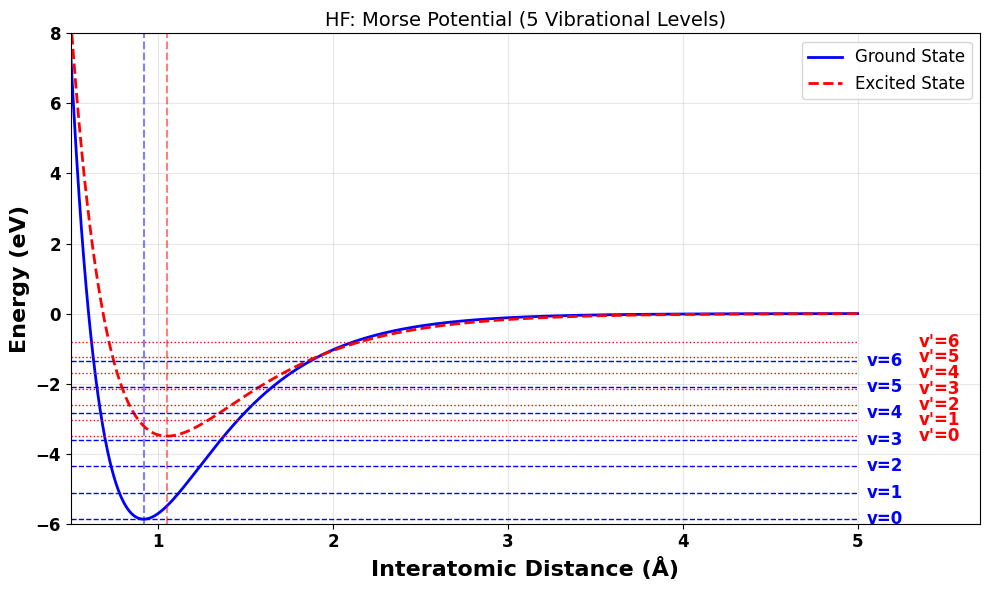

→ Plotting O2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


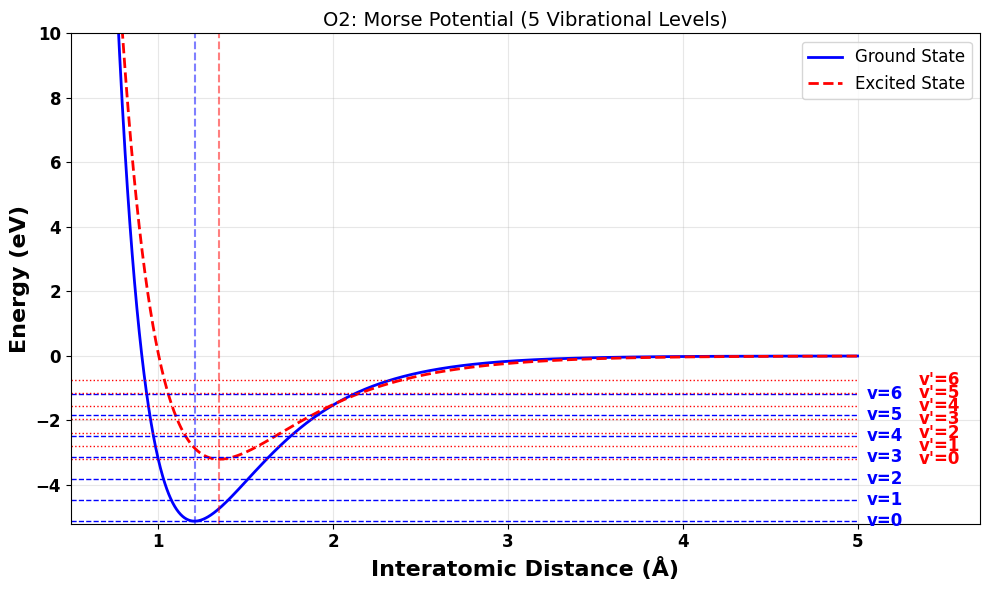

→ Plotting Br2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


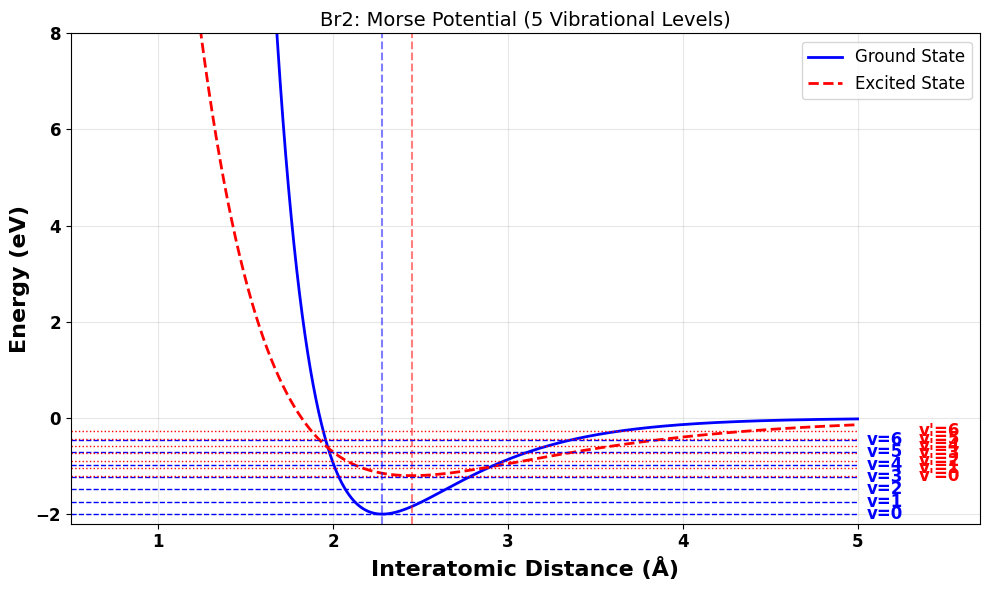

→ Plotting Cl2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


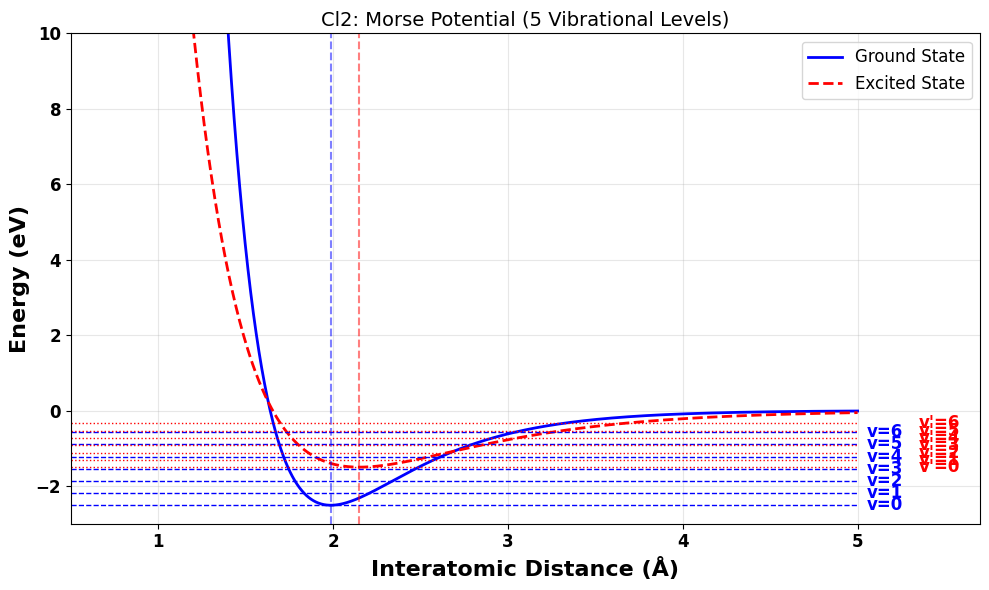

→ Plotting N2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


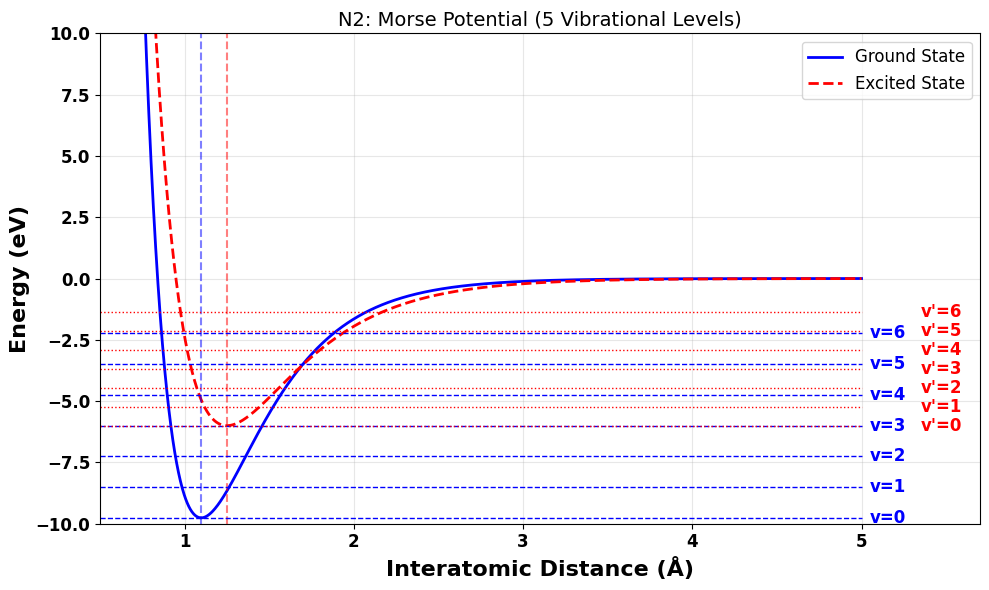

→ Plotting NO
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


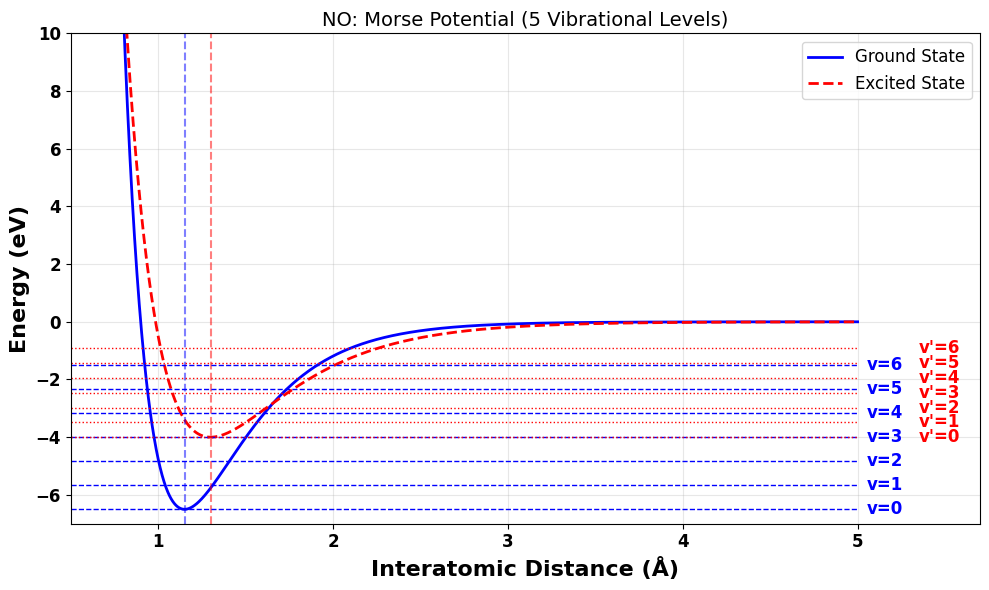

→ Plotting CO
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


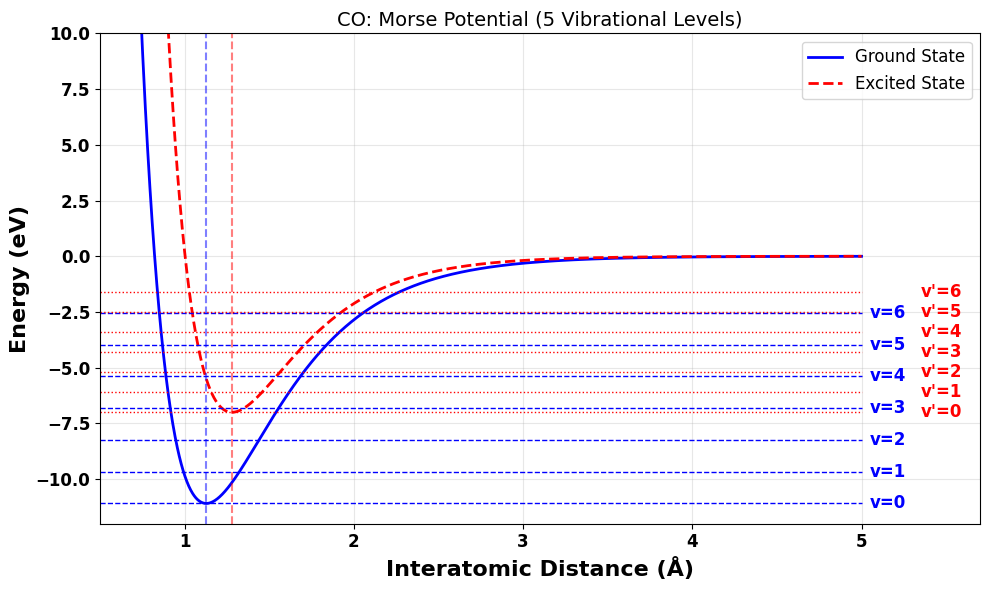


All plots generated successfully ✓

Molecule Data Table
Molecule   | E_min (Ground)     | Re (Ground)     | E_min (Excited)      | Re (Excited)   
------------------------------------------------------------------------------------------
HCl        | -4.620             | 1.274           | -2.800               | 1.400          
HBr        | -3.760             | 1.414           | -2.300               | 1.550          
HI         | -3.060             | 1.609           | -1.900               | 1.750          
HF         | -5.870             | 0.917           | -3.500               | 1.050          
O2         | -5.120             | 1.208           | -3.200               | 1.350          
Br2        | -2.000             | 2.281           | -1.200               | 2.450          
Cl2        | -2.510             | 1.987           | -1.500               | 2.150          
N2         | -9.760             | 1.098           | -6.000               | 1.250          
NO         | -6.500             |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
class MorsePotential:
   """
   Morse Potential Model with fewer vibrational levels
   and extended Y-axis
   """

   def __init__(self, name, ground, excited):
       self.name = name

       # Ground state
       self.De_g = ground["De"]
       self.a_g = ground["a"]
       self.re_g = ground["re"]

       # Excited state
       self.De_e = excited["De"]
       self.a_e = excited["a"]
       self.re_e = excited["re"]

   def energy(self, r, De, a, re):
       return De * (1 - np.exp(-a * (r - re)))**2 - De

   def plot(self):
       r = np.linspace(0.5, 5.0, 2000)

       # Potentials
       Vg = self.energy(r, self.De_g, self.a_g, self.re_g)
       Ve = self.energy(r, self.De_e, self.a_e, self.re_e)

       plt.figure(figsize=(10, 6))

       # -------- CURVES --------
       plt.plot(r, Vg, color='blue', linewidth=2, label="Ground State")
       plt.plot(r, Ve, color='red', linestyle="--", linewidth=2, label="Excited State")

       # -------- EQUILIBRIUM --------
       plt.axvline(self.re_g, color='blue', linestyle="--", alpha=0.5)
       plt.axvline(self.re_e, color='red', linestyle="--", alpha=0.5)

       # -------- VIBRATIONAL LEVELS --------
       n_levels = 7  # 🔥 reduced

       # Ground state (BLUE)
       spacing_g = (0.9 * self.De_g) / n_levels
       for v in range(n_levels):
           E = -self.De_g + v * spacing_g

           plt.hlines(E, min(r), max(r),
                      colors='blue', linestyles="dashed", linewidth=1)

           plt.text(max(r) + 0.05, E,
                    f"v={v}", fontsize=12, weight='bold', color='blue', va='center')

       # Excited state (RED)
       spacing_e = (0.9 * self.De_e) / n_levels
       for v in range(n_levels):
           E = -self.De_e + v * spacing_e

           plt.hlines(E, min(r), max(r),
                      colors='red', linestyles="dotted", linewidth=1)

           plt.text(max(r) + 0.35, E,
                    f"v'={v}", fontsize=12, weight='bold', color='red', va='center')


       # -------- AXIS --------
       if self.name == "HCl":
          plt.ylim(-5, 10)
       elif self.name == "HBr":
          plt.ylim(-4, 10)
       elif self.name == "HI":
           plt.ylim(-3.2, 10)
       elif self.name == "HF":
           plt.ylim(-6, 8)
       elif self.name == "O2":
           plt.ylim(-5.2, 10)
       elif self.name == "Br2":
           plt.ylim(-2.2, 8)
       elif self.name == "Cl2":
           plt.ylim(-3, 10)
       elif self.name == "N2":
           plt.ylim(-10, 10)
       elif self.name == "NO":
           plt.ylim(-7, 10)
       elif self.name == "CO":
           plt.ylim(-12, 10)

       plt.xlim(min(r), max(r) + 0.7)

       # -------- STYLE --------
       plt.title(f"{self.name}: Morse Potential (5 Vibrational Levels)", fontsize=14)
       plt.xlabel("Interatomic Distance (Å)", fontsize=16, weight='bold')
       plt.ylabel("Energy (eV)", fontsize=16, weight='bold')
       plt.xticks(fontsize=12, weight='bold')  # Increase font size for x axis tick marks
       plt.yticks(fontsize=12, weight='bold')  # Increase font size for y axis tick marks
       plt.legend( fontsize=12)  # Add legend for clarity
       plt.grid(alpha=0.3)
       plt.tight_layout()
       from google.colab import drive
       drive.mount('/content/drive')
       plt.savefig('/content/drive/My Drive/Harmonic/self.name.jpg', dpi=300)
       plt.show()

def print_molecule_table(molecules):
       print("\n" + "=" * 95)
       print("Molecule Data Table")
       print("=" * 95)

       header = f"{'Molecule':<10} | {'E_min (Ground)':<18} | {'Re (Ground)':<15} | {'E_min (Excited)':<20} | {'Re (Excited)':<15}"
       print(header)
       print("-" * len(header))

       for mol in molecules:
           name = mol["name"]

           De_g = mol["ground"]["De"]
           re_g = mol["ground"]["re"]

           De_e = mol["excited"]["De"]
           re_e = mol["excited"]["re"]

           # Morse minimum = -De
           Emin_g = -De_g
           Emin_e = -De_e

           print(f"{name:<10} | {Emin_g:<18.3f} | {re_g:<15.3f} | {Emin_e:<20.3f} | {re_e:<15.3f}")

       print("=" * 95 + "\n")

# -------------------- DATA --------------------
MOLECULES = [
   {"name": "HCl",
    "ground": {"De": 4.62, "a": 1.87, "re": 1.274},
    "excited": {"De": 2.8, "a": 1.5, "re": 1.40}},

   {"name": "HBr",
    "ground": {"De": 3.76, "a": 1.84, "re": 1.414},
    "excited": {"De": 2.3, "a": 1.4, "re": 1.55}},

   {"name": "HI",
    "ground": {"De": 3.06, "a": 1.79, "re": 1.609},
    "excited": {"De": 1.9, "a": 1.2, "re": 1.75}},

   {"name": "HF",
    "ground": {"De": 5.87, "a": 2.20, "re": 0.917},
    "excited": {"De": 3.5, "a": 1.9, "re": 1.05}},

   {"name": "O2",
    "ground": {"De": 5.12, "a": 2.30, "re": 1.208},
    "excited": {"De": 3.2, "a": 2.0, "re": 1.35}},

   {"name": "Br2",
    "ground": {"De": 2.00, "a": 1.95, "re": 2.281},
    "excited": {"De": 1.2, "a": 1.1, "re": 2.45}},

   {"name": "Cl2",
    "ground": {"De": 2.51, "a": 2.00, "re": 1.987},
    "excited": {"De": 1.5, "a": 1.4, "re": 2.15}},

   {"name": "N2",
    "ground": {"De": 9.76, "a": 2.69, "re": 1.098},
    "excited": {"De": 6.0, "a": 2.3, "re": 1.25}},

   {"name": "NO",
    "ground": {"De": 6.50, "a": 2.76, "re": 1.151},
    "excited": {"De": 4.0, "a": 2.20, "re": 1.30}},

   {"name": "CO",
    "ground": {"De": 11.09, "a": 2.27, "re": 1.128},
    "excited": {"De": 7.0, "a": 2.5, "re": 1.28}},
]


# -------------------- MAIN --------------------
def main():
   print("=" * 50)
   print("   Morse Potential (5 Vibrational Levels, Extended Y-axis)")
   print("=" * 50)

   for mol in MOLECULES:
       print(f"→ Plotting {mol['name']}")

       model = MorsePotential(
           mol["name"],
           mol["ground"],
           mol["excited"]
       )

       model.plot()

   print("\nAll plots generated successfully ✓")

   print_molecule_table(MOLECULES)
if __name__ == "__main__":
   main()